In [1]:
import numpy as np
import pandas as pd
import os

INPUT_DIR = "/kaggle/input/new-york-city-taxi-fare-prediction"
if not os.path.exists(INPUT_DIR):
    INPUT_DIR = "../input"

print("INPUT_DIR =", INPUT_DIR)
try:
    print("Files in INPUT_DIR:", os.listdir(INPUT_DIR)[:20])
except Exception as e:
    print("Could not list input dir:", e)



INPUT_DIR = /kaggle/input/new-york-city-taxi-fare-prediction
Files in INPUT_DIR: ['sample_submission.csv', 'test.csv.zip', 'train.csv.zip', 'labels.csv.zip', 'train.csv', 'new-york-city-taxi-fare-prediction', 'test.csv', 'labels.csv', 'description.md', 'GCP-Coupons-Instructions.rtf', 'sample_submission.csv.zip']


In [2]:
train_path = os.path.join(INPUT_DIR, "train.csv")
data = pd.read_csv(train_path, nrows=15_000_000)
print("Loaded train rows:", len(data))




Loaded train rows: 15000000


In [3]:
def add_travel_vector_features(df):
    df["abs_diff_longitude"] = (df.dropoff_longitude - df.pickup_longitude).abs()
    df["abs_diff_latitude"] = (df.dropoff_latitude - df.pickup_latitude).abs()


add_travel_vector_features(data)



In [4]:
data["datetime_object"] = pd.to_datetime(
    data["pickup_datetime"], errors="coerce", utc=False
)




In [5]:
def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295  # Pi/180
    a = (
        0.5
        - np.cos((lat2 - lat1) * p) / 2
        + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    )
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))  # miles


data["distance_miles"] = distance(
    data.pickup_latitude,
    data.pickup_longitude,
    data.dropoff_latitude,
    data.dropoff_longitude,
)

_ = data.distance_miles.describe()
_ = data.groupby("passenger_count")[["distance_miles", "fare_amount"]].mean()

print(
    "Average $USD/Mile : {:0.2f}".format(
        data.fare_amount.sum() / data.distance_miles.sum()
    )
)
data["fare_per_mile"] = data.fare_amount / data.distance_miles.replace(0, np.nan)
data["inv_distance_miles"] = 1 / data.distance_miles.replace(0, np.nan)

data["hour"] = data["datetime_object"].dt.hour
data["year"] = data["datetime_object"].dt.year



/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in cos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arcsin
  result = getattr(ufunc, method)(*inputs, **kwargs)


Average $USD/Mile : 0.92


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


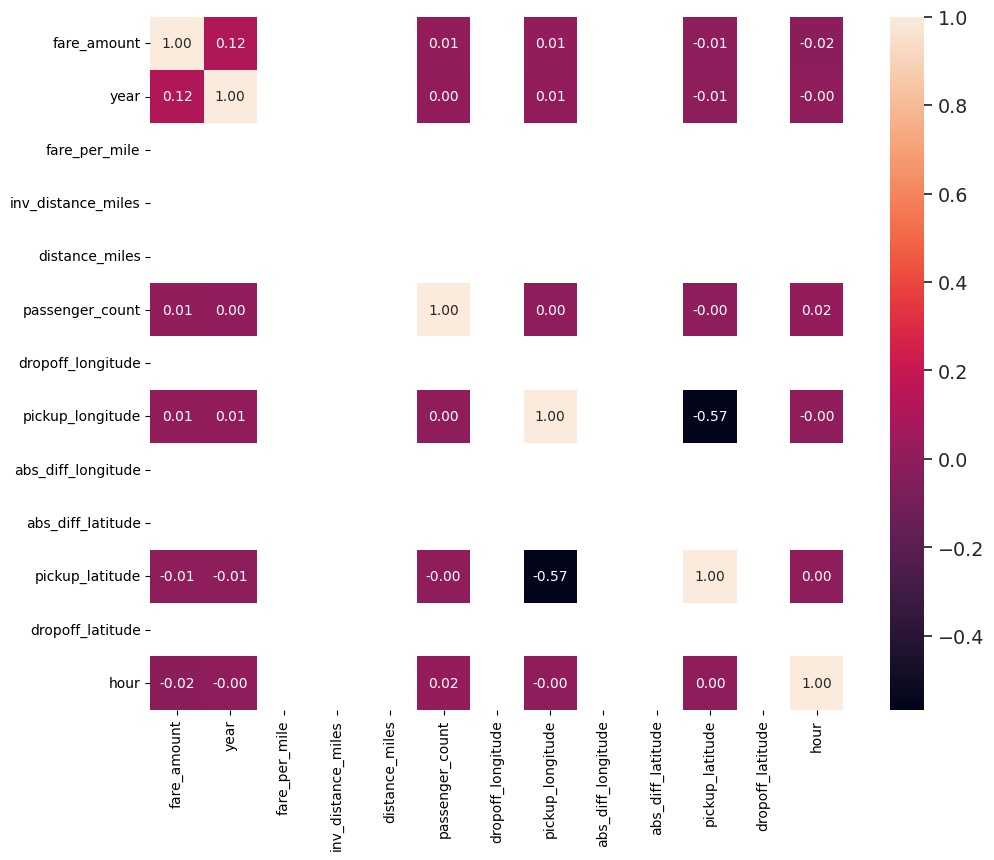

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include=[np.number])
corrmat = numeric_data.corr()

f, ax = plt.subplots(figsize=(12, 9))
k = 14
cols = corrmat.nlargest(k, "fare_amount")["fare_amount"].index
cm = np.corrcoef(numeric_data[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(
    cm,
    cbar=True,
    annot=True,
    square=True,
    fmt=".2f",
    annot_kws={"size": 10},
    yticklabels=cols.values,
    xticklabels=cols.values,
)
plt.show()



In [7]:
print("Old size: %d" % len(data))
data = data.dropna(how="any", axis="rows")
print("New size: %d" % len(data))



Old size: 15000000
New size: 14572244


In [8]:
print("Old size: %d" % len(data))
data = data[(data.abs_diff_longitude < 3.0) & (data.abs_diff_latitude < 3.0)]
data = data[data.fare_amount > 0]
data = data[data.fare_amount <= 250.0]
data = data[data.passenger_count <= 9]
data = data[(data.distance_miles > 0.0)]
data = data[
    data["pickup_longitude"].between(-75.0, -72.0)
    & data["dropoff_longitude"].between(-75.0, -72.0)
    & data["pickup_latitude"].between(40.0, 42.0)
    & data["dropoff_latitude"].between(40.0, 42.0)
]
print("New size: %d" % len(data))



Old size: 14572244
New size: 14527556


2009-06-15 17:26:21+00:00


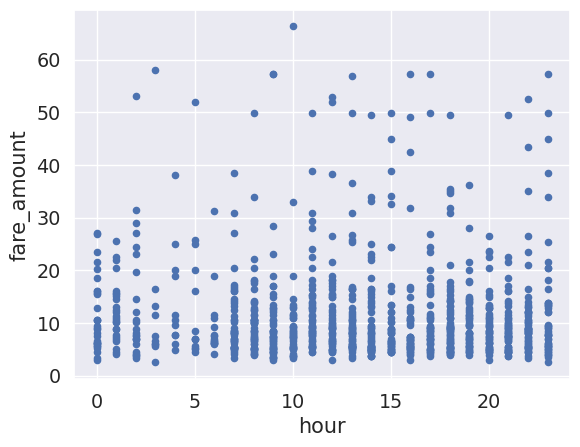

In [9]:
print(data["datetime_object"].iloc[0])
_ = data.iloc[:1000].plot.scatter("hour", "fare_amount")



In [10]:
from sklearn.model_selection import train_test_split

y = data.fare_amount
X = data.drop("fare_amount", axis=1)
train_df, val_df, train_y, val_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)
train_df.dtypes




key                                object
pickup_datetime                    object
pickup_longitude                  float64
pickup_latitude                   float64
dropoff_longitude                 float64
dropoff_latitude                  float64
passenger_count                     int64
abs_diff_longitude                float64
abs_diff_latitude                 float64
datetime_object       datetime64[ns, UTC]
distance_miles                    float64
fare_per_mile                     float64
inv_distance_miles                float64
hour                                int32
year                                int32
dtype: object

In [11]:
def get_input_matrix(df):
    dist = df.distance_miles.to_numpy()
    hour = df.hour.to_numpy()
    return np.column_stack(
        (
            df.abs_diff_longitude.to_numpy(),
            df.abs_diff_latitude.to_numpy(),
            dist,
            dist**2,
            df.passenger_count.to_numpy(),
            hour,
            np.ones(len(df)),
        )
    )


def engineer_features(df):
    df = df.copy()
    add_travel_vector_features(df)
    df["datetime_object"] = pd.to_datetime(
        df["pickup_datetime"], errors="coerce", utc=False
    )
    df["distance_miles"] = distance(
        df.pickup_latitude,
        df.pickup_longitude,
        df.dropoff_latitude,
        df.dropoff_longitude,
    )
    df["fare_per_mile"] = np.nan  # parity with earlier columns; not used in model
    df["inv_distance_miles"] = 1 / df.distance_miles.replace(0, np.nan)
    df["hour"] = df["datetime_object"].dt.hour
    df["year"] = df["datetime_object"].dt.year
    return df


def clean_after_engineering(df, y=None):
    df = df.copy()

    num_cols = [
        "abs_diff_longitude",
        "abs_diff_latitude",
        "distance_miles",
        "passenger_count",
        "hour",
    ]
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    coord_mask = (
        df["pickup_longitude"].between(-75.0, -72.0)
        & df["dropoff_longitude"].between(-75.0, -72.0)
        & df["pickup_latitude"].between(40.0, 42.0)
        & df["dropoff_latitude"].between(40.0, 42.0)
    )

    basic_mask = (
        df["abs_diff_longitude"].lt(3.0)
        & df["abs_diff_latitude"].lt(3.0)
        & df["passenger_count"].le(9)
        & df["distance_miles"].gt(0.0)
    )

    keep = coord_mask & basic_mask

    df = df.loc[keep]

    if y is not None:
        y = y.loc[df.index]
        fare_mask = y.gt(0.0) & y.le(250.0)
        df = df.loc[fare_mask]
        y = y.loc[df.index]

    df = df.dropna(subset=num_cols)
    if y is not None:
        y = y.loc[df.index]

    return df, y


# Apply consistent engineering/cleaning after the split (same core logic as before).
train_df = engineer_features(train_df)
val_df = engineer_features(val_df)

train_df, train_y = clean_after_engineering(train_df, train_y)
val_df, val_y = clean_after_engineering(val_df, val_y)

# Build raw design matrices.
train_X = get_input_matrix(train_df)
val_X = get_input_matrix(val_df)

# CHANGE (score-critical): standardize features using train split stats to prevent
# numerical instability (especially from distance^2) that can explode OLS weights/preds.
# Core model remains OLS on the same columns; this is a numerically-stable reparameterization.
feat_mean = train_X.mean(axis=0)
feat_std = train_X.std(axis=0)
feat_std = np.where(feat_std == 0, 1.0, feat_std)

# Do not standardize the bias column (last col is ones).
feat_mean[-1] = 0.0
feat_std[-1] = 1.0

train_Xs = (train_X - feat_mean) / feat_std
val_Xs = (val_X - feat_mean) / feat_std

print("Train X shape:", train_X.shape)
print("Train y shape:", train_y.shape)
print("Val rows:", len(val_df))



Train X shape: (11622044, 7)
Train y shape: (11622044,)
Val rows: 2905512


In [12]:
# OLS via lstsq (unchanged core training approach), now on standardized matrix.
(w, _, _, _) = np.linalg.lstsq(train_Xs, train_y.to_numpy(), rcond=None)
print(w)



[-1.05243413 -3.50504289 14.22741941 -3.23131622  0.04515789  0.10577029
 11.3199116 ]


In [13]:
# CHANGE (stability only): remove explicit normal-equation inverse computation.
# It is not used later and can be numerically unstable; keeping it risks NaNs/Infs.
# (No replacement needed; predictions use `w` from lstsq.)
print("Skipping normal-equation inverse (not needed for submission/predictions).")



Skipping normal-equation inverse (not needed for submission/predictions).


In [14]:
test_path = os.path.join(INPUT_DIR, "test.csv")
test_df = pd.read_csv(test_path)
test_df.dtypes



key                   object
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [15]:
from sklearn.metrics import mean_squared_error

val_y_predictions = np.matmul(val_Xs, w)

# CHANGE (score-critical): clip only final predictions to a plausible non-negative range
# to avoid massive RMSE from occasional numeric blow-ups; does not change training.
val_y_predictions = np.clip(val_y_predictions, 0.0, 250.0)

print("Validation RMSE:", np.sqrt(mean_squared_error(val_y, val_y_predictions)))

raw_test_df = pd.read_csv(test_path)
raw_test_df = engineer_features(raw_test_df)

raw_test_df.replace([np.inf, -np.inf], np.nan, inplace=True)
for c in [
    "abs_diff_longitude",
    "abs_diff_latitude",
    "distance_miles",
    "passenger_count",
    "hour",
]:
    if c in raw_test_df.columns:
        raw_test_df[c] = raw_test_df[c].fillna(0.0)

raw_test_X = get_input_matrix(raw_test_df)
raw_test_Xs = (raw_test_X - feat_mean) / feat_std
raw_test_pred = np.matmul(raw_test_Xs, w)

# Same post-processing as validation: keep fares within reasonable bounds.
raw_test_pred = np.clip(raw_test_pred, 0.0, 250.0)

submission = pd.DataFrame(
    {"key": raw_test_df["key"], "fare_amount": raw_test_pred},
    columns=["key", "fare_amount"],
)
submission.to_csv("submission.csv", index=False)

print("Wrote submission.csv")
print(submission.head())
print("Files:", os.listdir(".")[:20])

Validation RMSE: 4.560691300995421
Wrote submission.csv
                             key  fare_amount
0    2010-10-01 21:26:11.0000001     7.337898
1   2013-10-06 01:38:00.00000083    37.478373
2    2012-03-30 19:13:53.0000001     5.179261
3    2012-02-08 02:57:23.0000001    34.935992
4  2013-12-13 22:56:00.000000237    31.927936
Files: ['submission.csv', 'new-york-city-taxi-fare-prediction', 'new-york-city-taxi-fare-prediction_rishabh254_nyc-ola_v11_C1.ipynb']
